In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from operator import add
llm = ChatAnthropic(model="claude-haiku-4-5-20251001")

In [3]:
class Sentiment(BaseModel):
    sentiment:Literal['positive', 'negative'] = Field(description="Sentiment of the given feedback")

In [4]:
class State(TypedDict):
    feedback:str
    sentiment:str
    llm_feedback:str

In [5]:
structured_llm = llm.with_structured_output(Sentiment)

In [6]:
def find_sentiment(state:State):
    res = structured_llm.invoke(state['feedback'])
    return {'sentiment':res.sentiment}

In [7]:
def positive(state:State):
    return {'feedback':"Thank you for the visit come again"}

In [8]:
def negative(state:State):
    review = f"for this negative review ->{state['feedback']} give a proper response to the user"
    result = llm.invoke(review)
    return {"llm_feedback":result.content}

In [9]:
def router(state:State)->Literal['positive', 'negative']:
    if state['sentiment'] == 'positive':
        return 'positive'
    else:
        return 'negative'

In [10]:
graph = StateGraph(State)

In [11]:
graph.add_node('positive', positive)
graph.add_node('negative', negative)
graph.add_node("find_sentiment", find_sentiment)

In [12]:
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', router)
graph.add_edge('negative', END)
graph.add_edge('positive', END)

In [13]:

workflow = graph.compile()

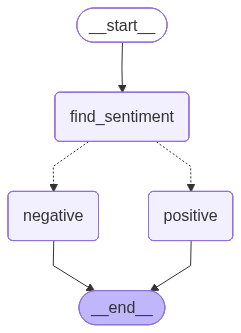

In [14]:
workflow

In [ ]:

workflow.invoke({'feedback':"this is such a bad product"})